#### End-to-End ML Pipeline: Customer Churn Prediction

**Objective:** Build a reusable, production-ready machine learning pipeline using Scikit-learn's `Pipeline` API to predict whether a telecom customer will churn.

**Dataset:** IBM Telco Customer Churn

**Approach:**
- Preprocess using `Pipeline` + `ColumnTransformer`
- Train Logistic Regression and Random Forest
- Tune both with `GridSearchCV`
- Export the best pipeline with `joblib` for reuse in production

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, RocCurveDisplay
)

SEED = 42


#### 1. Load Dataset

In [3]:
df = pd.read_csv('Telco-Customer-Churn.csv')

print(f"Shape  : {df.shape}")
print(f"Columns: {df.columns.tolist()}")
df.head()

Shape  : (7043, 21)
Columns: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


#### 2. Exploratory Data Analysis

In [4]:
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

Missing values:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
Payment

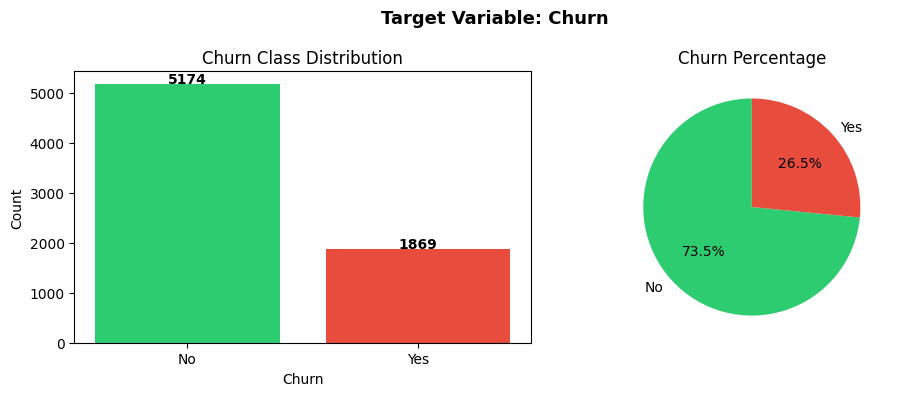

Churn
No     73.5
Yes    26.5
Name: proportion, dtype: float64


In [5]:
# Churn is our target
# Checking the class balance first
churn_counts = df['Churn'].value_counts()
churn_pct    = df['Churn'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(churn_counts.index, churn_counts.values, color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Churn Class Distribution')
axes[0].set_xlabel('Churn')
axes[0].set_ylabel('Count')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 30, str(v), ha='center', fontweight='bold')

axes[1].pie(churn_pct.values, labels=churn_pct.index, autopct='%1.1f%%',
            colors=['#2ecc71', '#e74c3c'], startangle=90)
axes[1].set_title('Churn Percentage')

plt.suptitle('Target Variable: Churn', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(churn_pct.round(1))

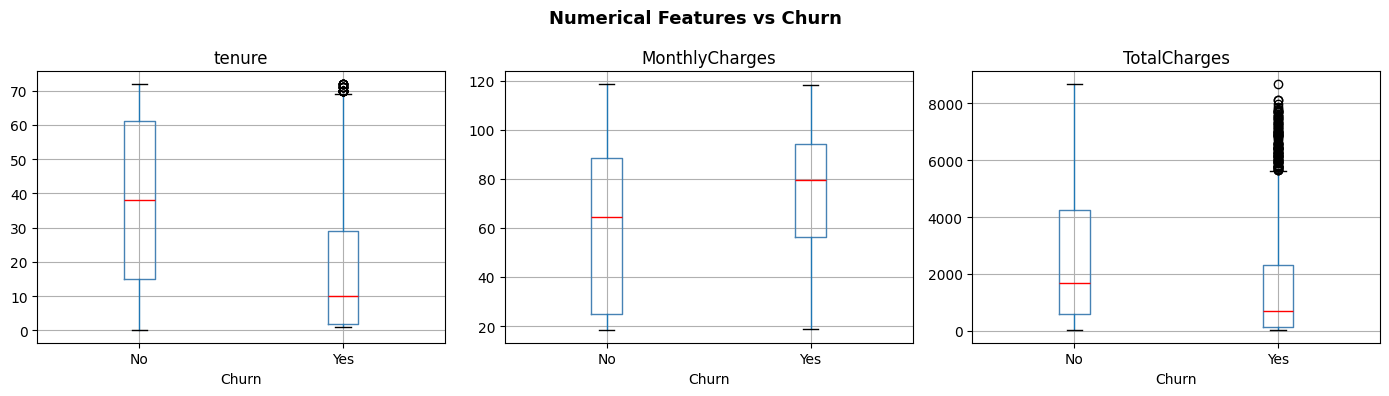

In [6]:
# Comparing numerical features between churners and non-churners
# tenure, MonthlyCharges, TotalCharges are the key billing signals
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for i, col in enumerate(num_cols):
    # convert to numeric just in case TotalCharges has whitespace issues
    df[col] = pd.to_numeric(df[col], errors='coerce')
    df.boxplot(column=col, by='Churn', ax=axes[i], 
               boxprops=dict(color='steelblue'),
               medianprops=dict(color='red'))
    axes[i].set_title(col)
    axes[i].set_xlabel('Churn')

plt.suptitle('Numerical Features vs Churn', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

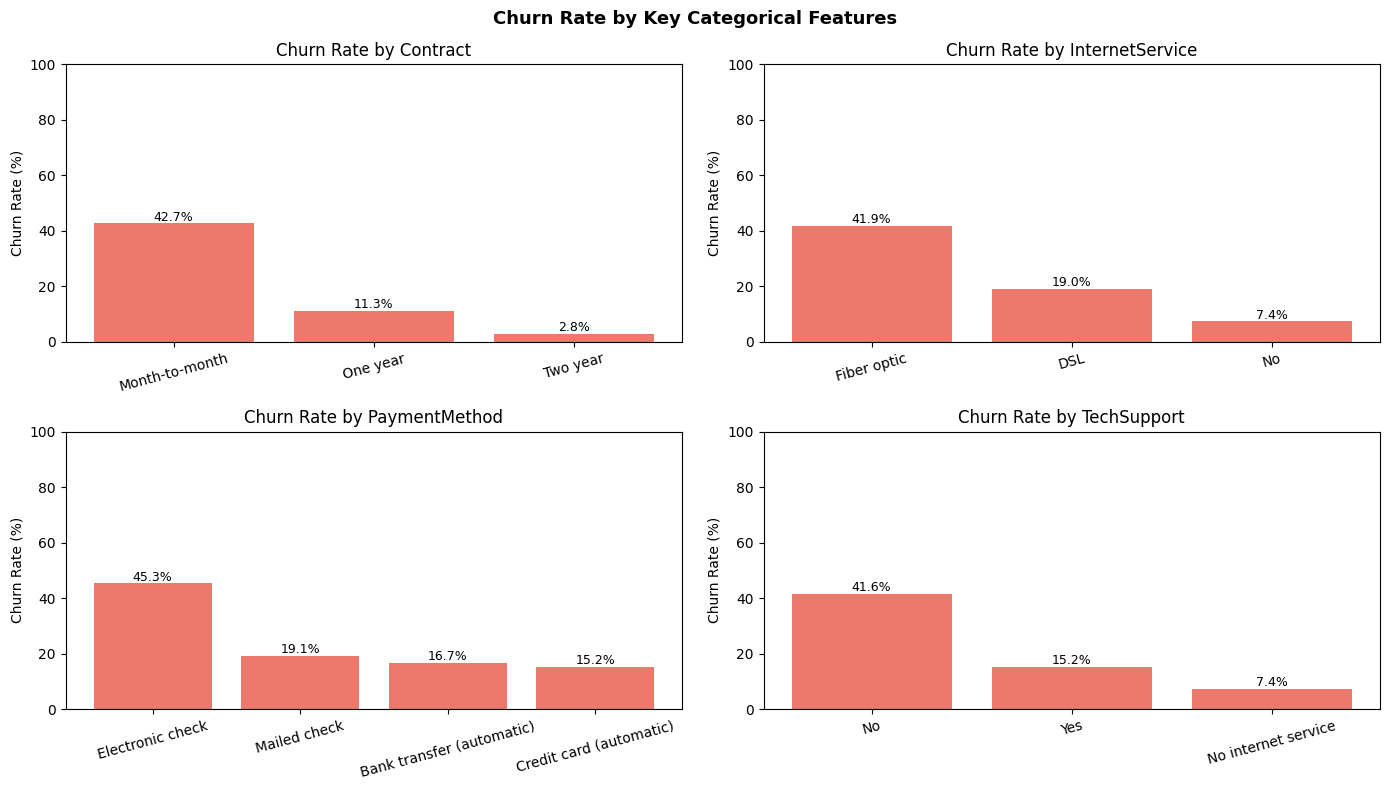

In [7]:
# Churn rate by contract type 
cat_features = ['Contract', 'InternetService', 'PaymentMethod', 'TechSupport']

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(cat_features):
    churn_rate = df.groupby(col)['Churn'].apply(
        lambda x: (x == 'Yes').mean() * 100
    ).sort_values(ascending=False)
    
    axes[i].bar(churn_rate.index, churn_rate.values, color='#e74c3c', alpha=0.75)
    axes[i].set_title(f'Churn Rate by {col}')
    axes[i].set_ylabel('Churn Rate (%)')
    axes[i].set_ylim(0, 100)
    axes[i].tick_params(axis='x', rotation=15)
    for j, v in enumerate(churn_rate.values):
        axes[i].text(j, v + 1, f'{v:.1f}%', ha='center', fontsize=9)

plt.suptitle('Churn Rate by Key Categorical Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

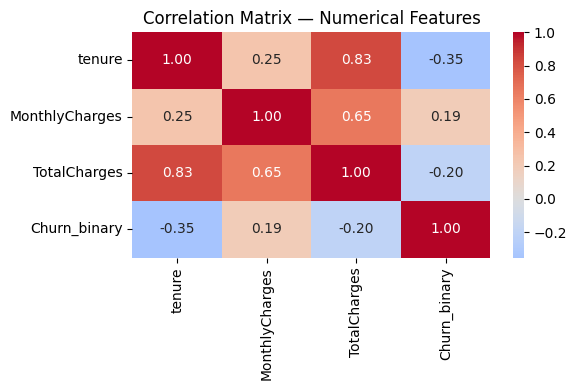

In [8]:
# Correlation heatmap for numerical features
num_df = df[num_cols].copy()
num_df['Churn_binary'] = (df['Churn'] == 'Yes').astype(int)

plt.figure(figsize=(6, 4))
sns.heatmap(num_df.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix — Numerical Features')
plt.tight_layout()
plt.show()

TotalCharges is highly correlated with tenure (longer customers = higher total spend)

#### 3. Preprocessing

In [9]:
df = df.drop(columns=['customerID'])

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
missing_before = df.shape[0]
df = df.dropna(subset=['TotalCharges'])
print(f"Dropped {missing_before - df.shape[0]} rows with missing TotalCharges")

# Encode the target:
df['Churn'] = (df['Churn'] == 'Yes').astype(int)

print(f"\nFinal shape: {df.shape}")
print(f"Churn distribution:\n{df['Churn'].value_counts()}")

Dropped 11 rows with missing TotalCharges

Final shape: (7032, 20)
Churn distribution:
Churn
0    5163
1    1869
Name: count, dtype: int64


In [10]:
# Separating features into numerical and categorical lists
# The Pipeline will apply different transformations to each group
X = df.drop(columns=['Churn'])
y = df['Churn']

numerical_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

print(f"Numerical features  ({len(numerical_features)}): {numerical_features}")
print(f"Categorical features ({len(categorical_features)}): {categorical_features}")

Numerical features  (4): ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical features (15): ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [ ]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

print(f"Train size : {X_train.shape[0]}  |  Churn rate: {y_train.mean():.2%}")
print(f"Test size  : {X_test.shape[0]}   |  Churn rate: {y_test.mean():.2%}")

Train size : 5625  |  Churn rate: 26.58%
Test size  : 1407   |  Churn rate: 26.58%


In [12]:
# ColumnTransformer applies different transformations to different column groups in parallel

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numerical_features),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features)
])

print("Preprocessor defined.")
print("  → Numerical  : StandardScaler")
print("  → Categorical: OneHotEncoder (drop='first', handle_unknown='ignore')")

Preprocessor defined.
  → Numerical  : StandardScaler
  → Categorical: OneHotEncoder (drop='first', handle_unknown='ignore')


#### 4. Pipelines & GridSearchCV

In [13]:
# Pipeline chains preprocessing and model into a single object
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier',   LogisticRegression(max_iter=1000, random_state=SEED))
])

# class_weight='balanced' accounts for the imbalanced churn classes
lr_param_grid = {
    'classifier__C'            : [0.01, 0.1, 1.0],
    'classifier__solver'       : ['lbfgs', 'liblinear'],
    'classifier__class_weight' : ['balanced', None]
}

print("Logistic Regression pipeline + param grid defined.")
print(f"Total LR combinations: {3 * 2 * 2} × 3 folds = {3*2*2*3} fits")

Logistic Regression pipeline + param grid defined.
Total LR combinations: 12 × 3 folds = 36 fits


In [14]:
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier',   RandomForestClassifier(random_state=SEED, n_jobs=-1))
])


rf_param_grid = {
    'classifier__n_estimators'  : [100, 200],
    'classifier__max_depth'     : [None, 10, 20],
    'classifier__class_weight'  : ['balanced', None]
}

print("Random Forest pipeline + param grid defined.")
print(f"Total RF combinations: {2 * 3 * 2} × 3 folds = {2*3*2*3} fits")

Random Forest pipeline + param grid defined.
Total RF combinations: 12 × 3 folds = 36 fits


In [ ]:

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)

print("Running GridSearchCV for Logistic Regression...")
lr_search = GridSearchCV(
    lr_pipeline, lr_param_grid,
    cv=cv, scoring='f1', n_jobs=-1, verbose=1
)
lr_search.fit(X_train, y_train)

print(f"\nBest LR params : {lr_search.best_params_}")
print(f"Best LR CV F1  : {lr_search.best_score_:.4f}")

Running GridSearchCV for Logistic Regression...
Fitting 3 folds for each of 12 candidates, totalling 36 fits

Best LR params : {'classifier__C': 1.0, 'classifier__class_weight': 'balanced', 'classifier__solver': 'lbfgs'}
Best LR CV F1  : 0.6333


In [16]:
print("Running GridSearchCV for Random Forest...")
rf_search = GridSearchCV(
    rf_pipeline, rf_param_grid,
    cv=cv, scoring='f1', n_jobs=-1, verbose=1
)
rf_search.fit(X_train, y_train)

print(f"\nBest RF params : {rf_search.best_params_}")
print(f"Best RF CV F1  : {rf_search.best_score_:.4f}")

Running GridSearchCV for Random Forest...
Fitting 3 folds for each of 12 candidates, totalling 36 fits

Best RF params : {'classifier__class_weight': 'balanced', 'classifier__max_depth': 10, 'classifier__n_estimators': 200}
Best RF CV F1  : 0.6323


#### 5. Evaluation & Model Comparison

In [17]:
# Evaluating both best models on the held-out test set
def evaluate_model(name, search, X_test, y_test):
    y_pred = search.best_estimator_.predict(X_test)
    y_prob = search.best_estimator_.predict_proba(X_test)[:, 1]
    return {
        'Model'    : name,
        'Accuracy' : accuracy_score(y_test, y_pred),
        'F1'       : f1_score(y_test, y_pred),
        'ROC-AUC'  : roc_auc_score(y_test, y_prob),
        'CV F1'    : search.best_score_
    }

lr_metrics = evaluate_model('Logistic Regression', lr_search, X_test, y_test)
rf_metrics = evaluate_model('Random Forest',       rf_search, X_test, y_test)

results_df = pd.DataFrame([lr_metrics, rf_metrics]).set_index('Model')
print(results_df.round(4))

                     Accuracy      F1  ROC-AUC   CV F1
Model                                                 
Logistic Regression    0.7264  0.6067   0.8353  0.6333
Random Forest          0.7726  0.6355   0.8360  0.6323


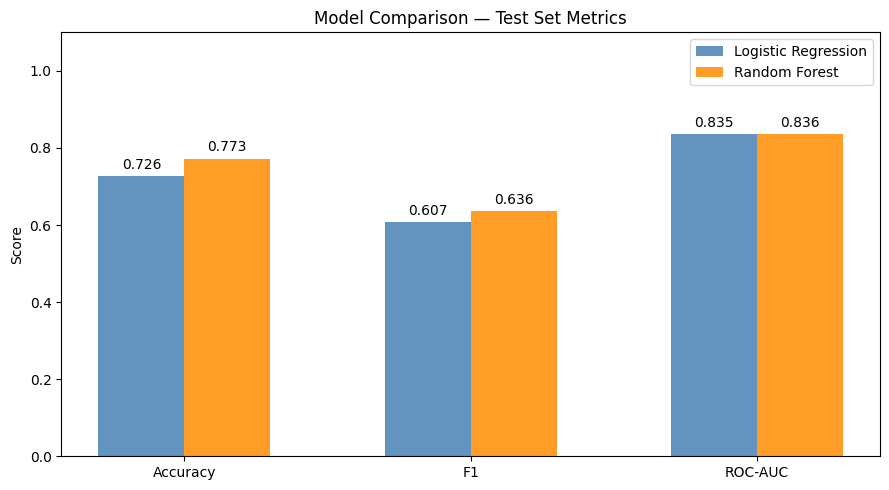

In [18]:
# Side-by-side metric comparison
metrics = ['Accuracy', 'F1', 'ROC-AUC']
x = np.arange(len(metrics))
width = 0.3

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width/2, results_df.loc['Logistic Regression', metrics], width,
               label='Logistic Regression', color='steelblue', alpha=0.85)
bars2 = ax.bar(x + width/2, results_df.loc['Random Forest', metrics], width,
               label='Random Forest', color='darkorange', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('Model Comparison — Test Set Metrics')
ax.legend()
ax.bar_label(bars1, fmt='%.3f', padding=3)
ax.bar_label(bars2, fmt='%.3f', padding=3)

plt.tight_layout()
plt.show()

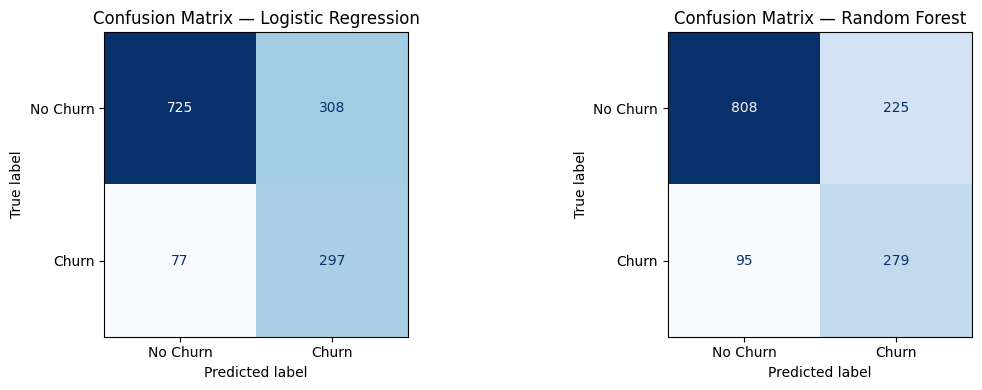

In [ ]:
# Confusion matrices for both models side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (name, search) in zip(axes, [
    ('Logistic Regression', lr_search),
    ('Random Forest',       rf_search)
]):
    y_pred = search.best_estimator_.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['No Churn', 'Churn'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'Confusion Matrix — {name}')

plt.tight_layout()
plt.show()

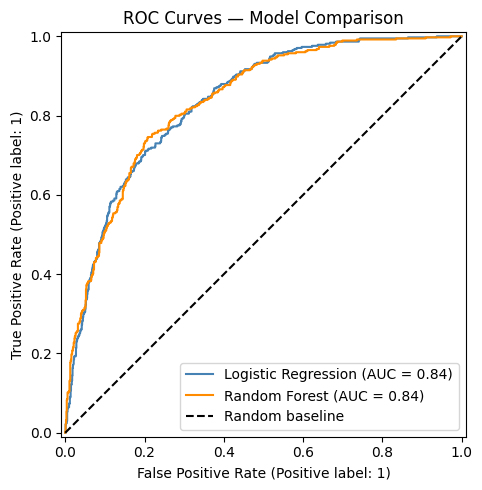

In [ ]:

fig, ax = plt.subplots(figsize=(7, 5))

for name, search, color in [
    ('Logistic Regression', lr_search, 'steelblue'),
    ('Random Forest',       rf_search, 'darkorange')
]:
    RocCurveDisplay.from_estimator(
        search.best_estimator_, X_test, y_test,
        name=name, ax=ax, color=color
    )

ax.plot([0, 1], [0, 1], 'k--', label='Random baseline')
ax.set_title('ROC Curves — Model Comparison')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

ROC curves: the higher and further left, the better

AUC close to 1.0 means the model ranks churners above non-churners reliably

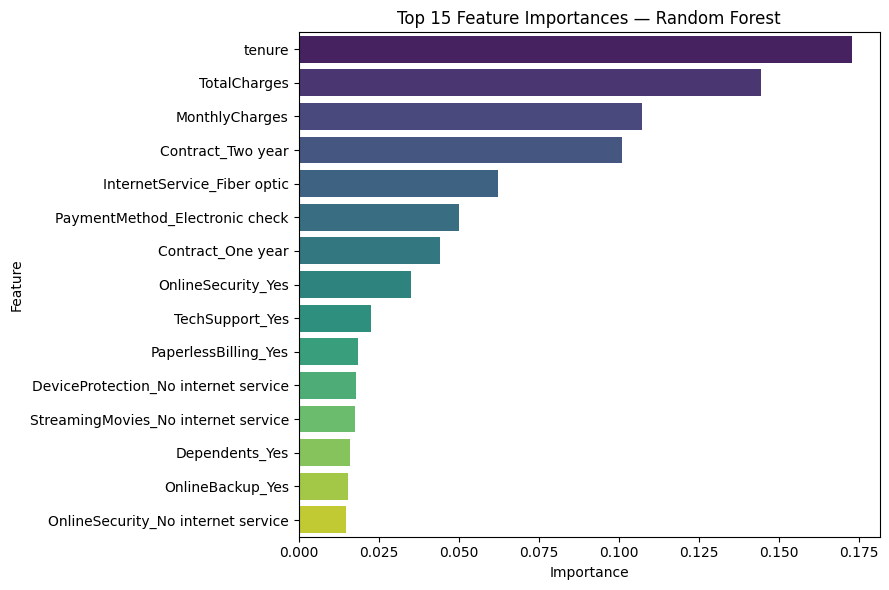

In [21]:
# Feature importances from Random Forest

rf_best = rf_search.best_estimator_
feature_names = (
    numerical_features +
    rf_best.named_steps['preprocessor']
        .named_transformers_['cat']
        .get_feature_names_out(categorical_features).tolist()
)

importances = rf_best.named_steps['classifier'].feature_importances_
imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
imp_df = imp_df.sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(9, 6))
sns.barplot(data=imp_df, x='Importance', y='Feature', palette='viridis')
plt.title('Top 15 Feature Importances — Random Forest')
plt.tight_layout()
plt.show()

In [22]:
# Detailed per-class breakdown for both models
for name, search in [('Logistic Regression', lr_search), ('Random Forest', rf_search)]:
    y_pred = search.best_estimator_.predict(X_test)
    print(f"{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))

  Logistic Regression
              precision    recall  f1-score   support

    No Churn       0.90      0.70      0.79      1033
       Churn       0.49      0.79      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.79      0.73      0.74      1407

  Random Forest
              precision    recall  f1-score   support

    No Churn       0.89      0.78      0.83      1033
       Churn       0.55      0.75      0.64       374

    accuracy                           0.77      1407
   macro avg       0.72      0.76      0.74      1407
weighted avg       0.80      0.77      0.78      1407



#### 6. Selecting Best Model & Export

In [23]:
# Picking the model with higher F1 on the test set

best_name, best_search = max(
    [('Logistic Regression', lr_search), ('Random Forest', rf_search)],
    key=lambda x: f1_score(y_test, x[1].best_estimator_.predict(X_test))
)

best_pipeline = best_search.best_estimator_

# joblib serializes the entire pipeline
joblib.dump(best_pipeline, 'churn_pipeline.pkl')

print(f"Best model    : {best_name}")
print(f"Best params   : {best_search.best_params_}")
print(f"Saved to      : churn_pipeline.pkl")

Best model    : Random Forest
Best params   : {'classifier__class_weight': 'balanced', 'classifier__max_depth': 10, 'classifier__n_estimators': 200}
Saved to      : churn_pipeline.pkl


#### 7. Summary 

**Key observations from EDA:**
- Month-to-month contract customers churn at a dramatically higher rate than annual/two-year customers
- Short tenure strongly correlates with churn, customers who leave tend to do so early
- Fiber optic internet customers churn more than DSL customers, possibly reflecting pricing dissatisfaction
- Customers without TechSupport churn more, bundled services increase retention

**Results summary:**
- Both models were tuned with GridSearchCV
- The better-performing pipeline was exported to `churn_pipeline.pkl` for use in `predict.py`
